In [1]:
# compare_rotinv_matching_rates.py

import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# ---- Your utilities (must exist in utilityFunctions*.py files) ----
from utilityFunctions import (
    load_csv_to_matrix_batch,
    compute_color_similarity_distance_batch,
    compute_color_preference_distance_batch,   # your new function (antisym + abs)
    show_heatmaps,  # not used in final figure but handy if you want to inspect
)
from utilityFunctions_GWOT import GWD_and_plot_rotational_OT  # your updated, rotation-aware version


# -------------------------
# Configuration
# -------------------------
folder_path = "raw_data/202411_data"   # adjust if needed
unique_colours = np.array([
    '#d2b700', '#db8b08', '#c7512c', '#c13547', '#a03663', '#753a7a',
    '#4b488e', '#005692', '#006a8b', '#007b75', '#008a52', '#9aa400'
])
colour_index = {c: i for i, c in enumerate(unique_colours)}
matrix_size = len(unique_colours)

# Epsilons for GWOT
n_eps = 25
eps_range = [0.04, 2]
epsilons = np.logspace(np.log10(eps_range[0]), np.log10(eps_range[1]), n_eps)

# Experiment
n_iterations = 5
rng_seed = 42   # set to None for different random splits each run


# -------------------------
# Load raw matrices
# -------------------------
# Raw similarity
response_type = "similarity"
subject_matrices_similarity_raw = load_csv_to_matrix_batch(
    folder_path, response_type, colour_index, matrix_size
)

# Raw preference
response_type = "preference"
subject_matrices_preference_raw = load_csv_to_matrix_batch(
    folder_path, response_type, colour_index, matrix_size
)

n_subjects = len(subject_matrices_similarity_raw)
assert n_subjects == len(subject_matrices_preference_raw), "Mismatch in subject counts."

Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.csv
raw_data/202411_data/subject_04_609c10.csv
raw_data/202411_data/subject_05_60d129.csv
raw_data/202411_data/subject_06_610814.csv
raw_data/202411_data/subject_07_6171f3.csv
raw_data/202411_data/subject_08_65a3ab.csv
raw_data/202411_data/subject_09_65f13c.csv
raw_data/202411_data/subject_10_65f18d.csv
raw_data/202411_data/subject_11_65fa3b.csv
raw_data/202411_data/subject_12_663180.csv
raw_data/202411_data/subject_13_667c6c.csv
raw_data/202411_data/subject_14_667df4.csv
raw_data/202411_data/subject_15_668110.csv
raw_data/202411_data/subject_16_6681ad.csv
raw_data/202411_data/subject_17_66906a.csv
raw_data/202411_data/subject_18_66a502.csv
raw_data/202411_data/subject_19_6734b5.csv
Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.

Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 3.7712868260344736, Matching Rate: 16.666666666666664
Epsilon: 0.04708151271794864, GWD: 3.639814964472486, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 3.639814996835354, Matching Rate: 16.666666666666664
Epsilon: 0.06522757635813241, GWD: 4.5783283600052975, Matching Rate: 16.666666666666664
Epsilon: 0.0767753241466594, GWD: 3.613271744451849, Matching Rate: 8.333333333333332
Epsilon: 0.09036746000588931, GWD: 3.6132724681981045, Matching Rate: 8.333333333333332
Epsilon: 0.1063659179388998, GWD: 3.613279049781017, Matching Rate: 8.333333333333332
Epsilon: 0.12519670795491478, GWD: 3.6133403057464193, Matching Rate: 8.333333333333332
Epsilon: 0.1473612599456155, GWD: 4.6097013884241775, Matching Rate: 8.333333333333332
Epsilon: 0.17344977585656074, GWD: 4.610325771244835, Matching Rate: 8.333333333333332
Epsilon: 0.20415694569790008, GWD: 4.413762208992871, Matching Rate: 16.666666666666664
Epsilon: 0.24030044588333074, GWD: 

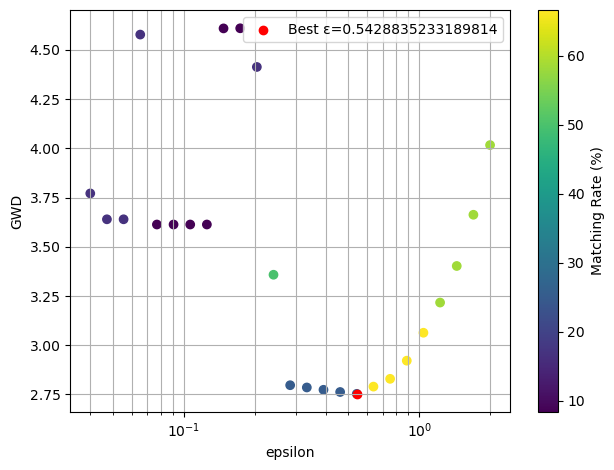

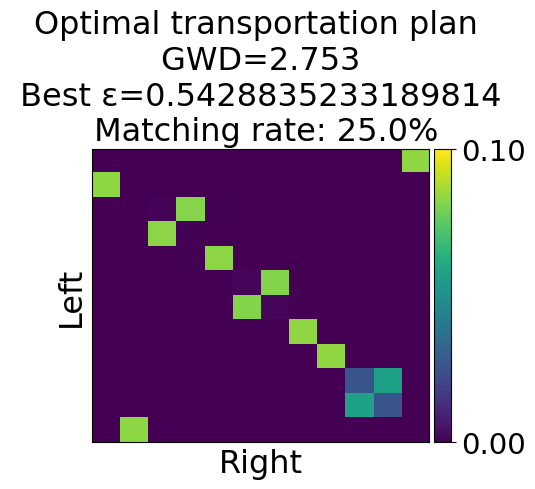

RotInv best candidate: shift_1, score=0.406
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.10609795750960765, Matching Rate: 16.666666666666664
Epsilon: 0.04708151271794864, GWD: 0.11242106489603905, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 0.12070375578328914, Matching Rate: 16.666666666666664
Epsilon: 0.06522757635813241, GWD: 0.130394127737447, Matching Rate: 16.666666666666664
Epsilon: 0.0767753241466594, GWD: 0.1412413964698994, Matching Rate: 16.666666666666664
Epsilon: 0.09036746000588931, GWD: 0.15390998889762614, Matching Rate: 16.666666666666664
Epsilon: 0.1063659179388998, GWD: 0.16956386154423278, Matching Rate: 16.666666666666664
Epsilon: 0.12519670795491478, GWD: 0.1899425549480564, Matching Rate: 16.666666666666664
Epsilon: 0.1473612599456155, GWD: 0.2160247875206206, Matching Rate: 8.333333333333332
Epsilon: 0.17344977585656074, GWD: 0.2283714565253505, Matching Rate: 8.333333333333332
Epsilon: 0.20415694569790008, GWD: 0.24521454601412657, Matching Rate: 8.333333333333332
Epsilon: 0.2403004458

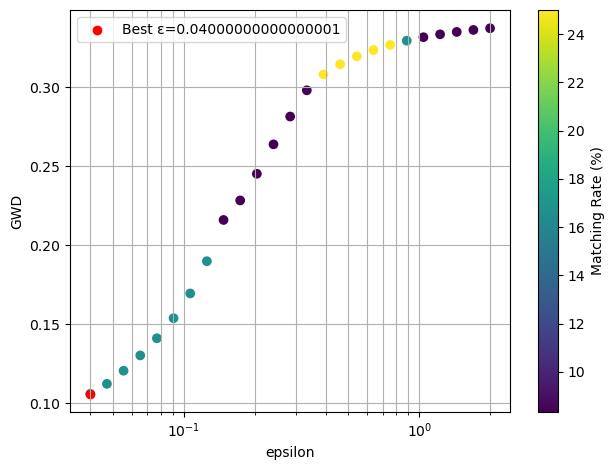

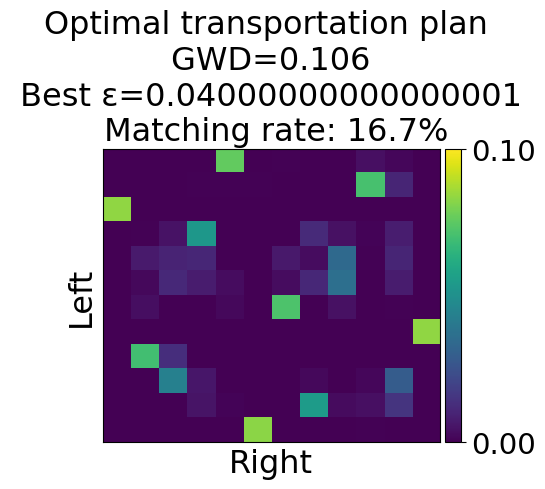

RotInv best candidate: shift_8, score=0.256
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 4.612119516250592, Matching Rate: 8.333333333333332
Epsilon: 0.04708151271794864, GWD: 3.4967880209228785, Matching Rate: 0.0
Epsilon: 0.055416720995258975, GWD: 4.08142424165027, Matching Rate: 8.333333333333332
Epsilon: 0.06522757635813241, GWD: 2.9600457301889973, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 2.960045273329863, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 2.9600455532318333, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 2.9600489650151034, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 2.9600622874198823, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 2.9600964412752377, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 2.960168502794353, Matching Rate: 0.0
Epsilon: 0.20415694569790008, GWD: 2.959767271233951, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 3.662504288368533, Matching Rate: 0.0
Epsilon: 0.28284271247461906, GWD: 3.6687068094543926, Matching Rate: 0.0
Epsilon: 0.33291656

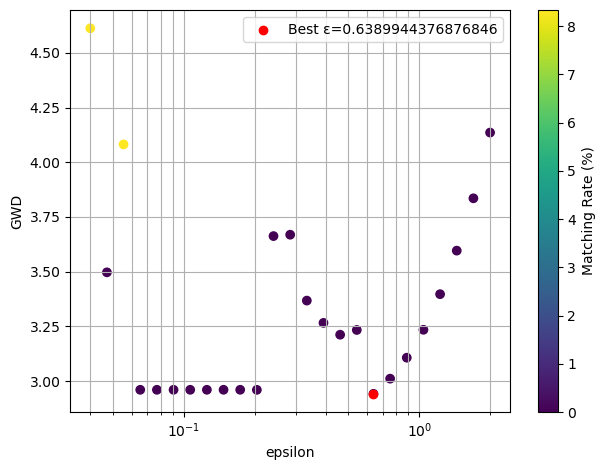

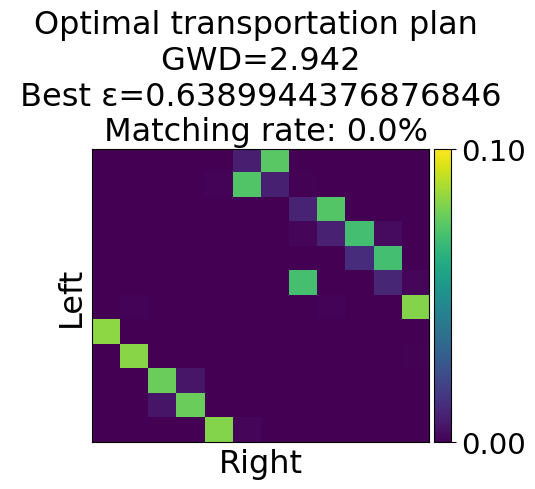

RotInv best candidate: shift_7, score=0.590
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.1485972382329325, Matching Rate: 16.666666666666664
Epsilon: 0.04708151271794864, GWD: 0.1558090186137845, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 0.165169103642214, Matching Rate: 25.0
Epsilon: 0.06522757635813241, GWD: 0.17732367232285445, Matching Rate: 25.0
Epsilon: 0.0767753241466594, GWD: 0.19333227308428438, Matching Rate: 16.666666666666664
Epsilon: 0.09036746000588931, GWD: 0.20752630801050498, Matching Rate: 16.666666666666664
Epsilon: 0.1063659179388998, GWD: 0.22159895338211977, Matching Rate: 16.666666666666664
Epsilon: 0.12519670795491478, GWD: 0.23626724073545863, Matching Rate: 16.666666666666664
Epsilon: 0.1473612599456155, GWD: 0.25187765901760756, Matching Rate: 16.666666666666664
Epsilon: 0.17344977585656074, GWD: 0.26938299685881656, Matching Rate: 16.666666666666664
Epsilon: 0.20415694569790008, GWD: 0.2886176227074214, Matching Rate: 16.666666666666664
Epsilon: 0.24030044588333074, GWD: 0.30701809

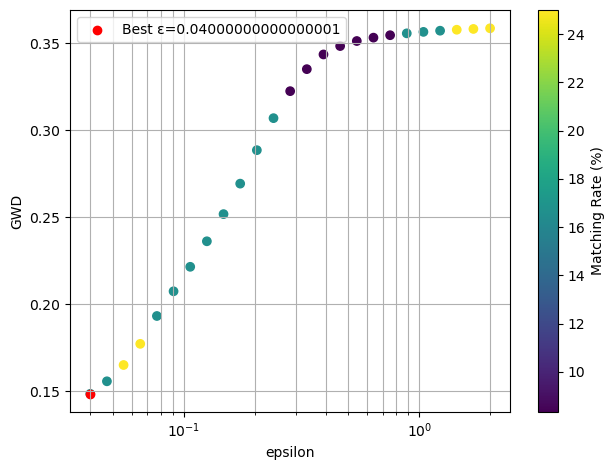

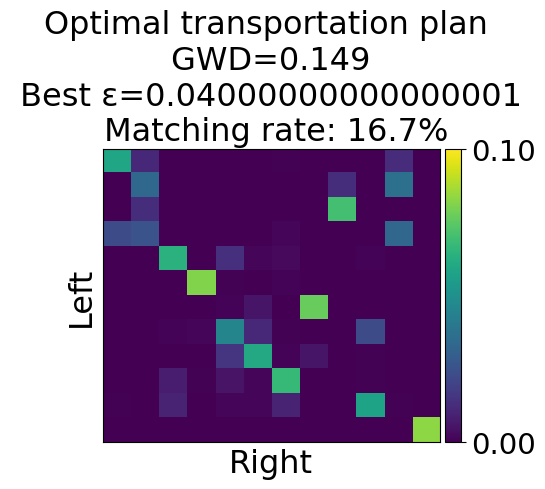

RotInv best candidate: shift_3, score=0.294
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 3.782885987086016, Matching Rate: 0.0
Epsilon: 0.04708151271794864, GWD: 3.7831596980573132, Matching Rate: 0.0
Epsilon: 0.055416720995258975, GWD: 3.7837636564341612, Matching Rate: 0.0
Epsilon: 0.06522757635813241, GWD: 3.784793939238676, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 2.8831276955218, Matching Rate: 25.0
Epsilon: 0.09036746000588931, GWD: 3.7987670260775235, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 3.800225419856959, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 3.8021134011528357, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 3.804521767487461, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 4.143106626501113, Matching Rate: 0.0
Epsilon: 0.20415694569790008, GWD: 2.4790417801219053, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 2.482836870596743, Matching Rate: 0.0
Epsilon: 0.28284271247461906, GWD: 2.3271742757686393, Matching Rate: 0.0
Epsilon: 0.3329165691138216, GWD: 2.325368813230

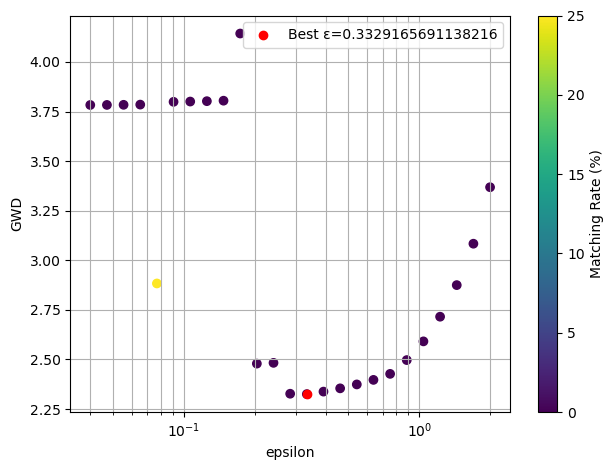

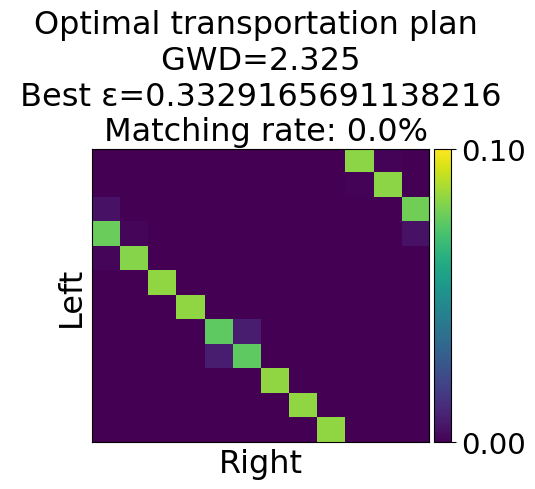

RotInv best candidate: shift_3, score=0.998
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.12085332042293304, Matching Rate: 16.666666666666664
Epsilon: 0.04708151271794864, GWD: 0.1275241837309789, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 0.1368203298700585, Matching Rate: 16.666666666666664
Epsilon: 0.06522757635813241, GWD: 0.15003275150265066, Matching Rate: 16.666666666666664
Epsilon: 0.0767753241466594, GWD: 0.16603349746912593, Matching Rate: 8.333333333333332
Epsilon: 0.09036746000588931, GWD: 0.18279245561055057, Matching Rate: 8.333333333333332
Epsilon: 0.1063659179388998, GWD: 0.19582382592079456, Matching Rate: 8.333333333333332
Epsilon: 0.12519670795491478, GWD: 0.20702073331257945, Matching Rate: 8.333333333333332
Epsilon: 0.1473612599456155, GWD: 0.21994458888600646, Matching Rate: 8.333333333333332
Epsilon: 0.17344977585656074, GWD: 0.23477239656351565, Matching Rate: 8.333333333333332
Epsilon: 0.20415694569790008, GWD: 0.25069494016689486, Matching Rate: 16.666666666666664
Epsilon: 0.240300445

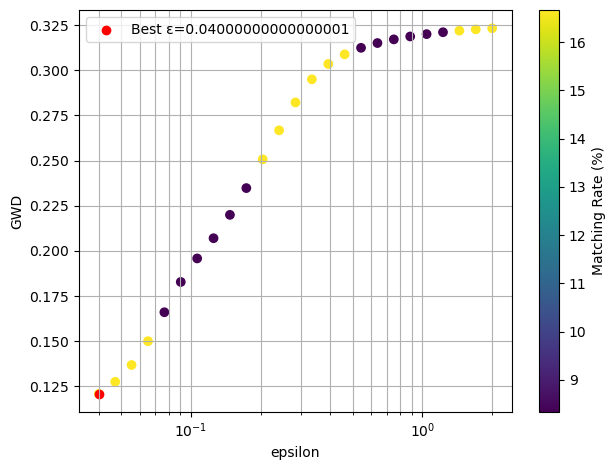

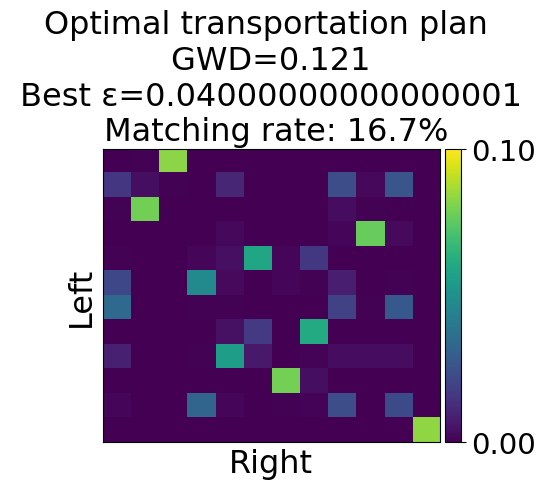

RotInv best candidate: shift_0, score=0.225
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 4.3855229527573565, Matching Rate: 0.0
Epsilon: 0.04708151271794864, GWD: 4.385540228291022, Matching Rate: 0.0
Epsilon: 0.055416720995258975, GWD: 4.385507582373904, Matching Rate: 0.0
Epsilon: 0.06522757635813241, GWD: 4.1899779948160365, Matching Rate: 8.333333333333332
Epsilon: 0.0767753241466594, GWD: 4.233358337874687, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 3.542103565695141, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 3.542308206129009, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 3.515312661105537, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 3.4095286495459405, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 3.977496602064352, Matching Rate: 8.333333333333332
Epsilon: 0.20415694569790008, GWD: 4.406561047441173, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 4.66416316352365, Matching Rate: 0.0
Epsilon: 0.28284271247461906, GWD: 3.4839226083660235, Matching Rate: 0.0
Epsilon: 0.33291656911

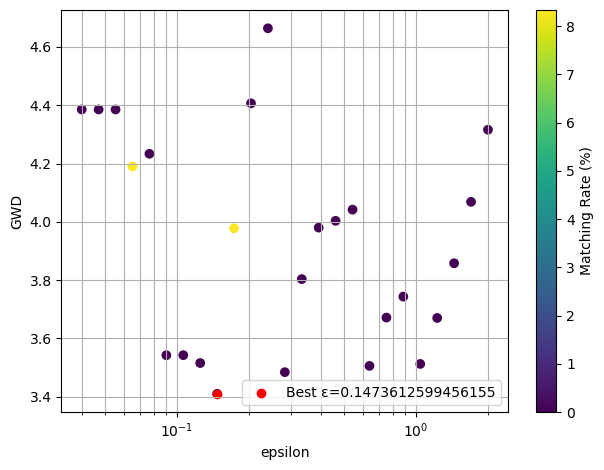

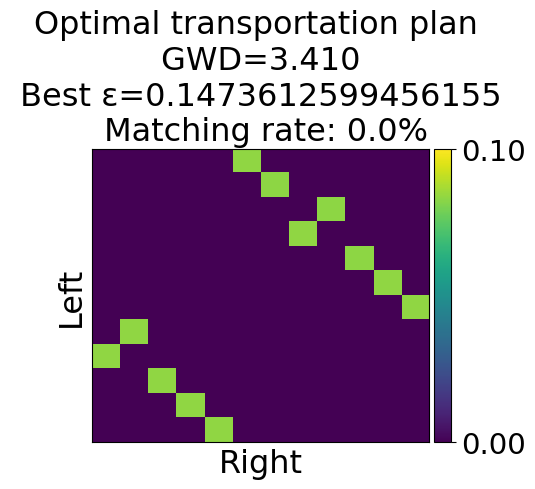

RotInv best candidate: shift_7, score=0.667
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.18601093955233625, Matching Rate: 33.33333333333333
Epsilon: 0.04708151271794864, GWD: 0.19177914871976107, Matching Rate: 33.33333333333333
Epsilon: 0.055416720995258975, GWD: 0.19902549522612892, Matching Rate: 33.33333333333333
Epsilon: 0.06522757635813241, GWD: 0.20776859566814343, Matching Rate: 33.33333333333333
Epsilon: 0.0767753241466594, GWD: 0.21826001959241292, Matching Rate: 33.33333333333333
Epsilon: 0.09036746000588931, GWD: 0.23054152888863194, Matching Rate: 33.33333333333333
Epsilon: 0.1063659179388998, GWD: 0.24446907125976353, Matching Rate: 33.33333333333333
Epsilon: 0.12519670795491478, GWD: 0.26011952372918534, Matching Rate: 33.33333333333333
Epsilon: 0.1473612599456155, GWD: 0.278556430511124, Matching Rate: 33.33333333333333
Epsilon: 0.17344977585656074, GWD: 0.30249891613493896, Matching Rate: 33.33333333333333
Epsilon: 0.20415694569790008, GWD: 0.2971608486759492, Matching Rate: 16.666666666666664
Epsilon: 0.24030044588333

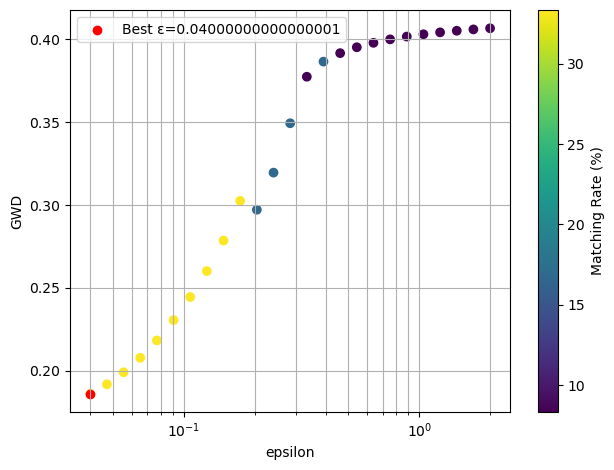

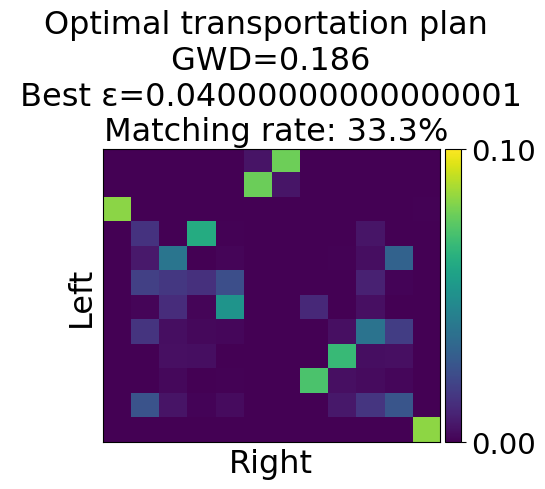

RotInv best candidate: shift_5_rot90, score=0.371
Computing Gromov-Wasserstein distances and optimal transport plans...
Epsilon: 0.04000000000000001, GWD: 3.567772648773096, Matching Rate: 0.0
Epsilon: 0.04708151271794864, GWD: 3.567772060477724, Matching Rate: 0.0


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.055416720995258975, GWD: 3.566547623619786, Matching Rate: 0.0
Epsilon: 0.06522757635813241, GWD: 3.5665437412479175, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 3.566541009813884, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 3.566547406810313, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 2.9599733176166882, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 2.9605889386759885, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 2.9616184688261975, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 2.922299481652032, Matching Rate: 8.333333333333332
Epsilon: 0.20415694569790008, GWD: 3.7570917837547393, Matching Rate: 8.333333333333332
Epsilon: 0.24030044588333074, GWD: 3.7797624283531777, Matching Rate: 8.333333333333332
Epsilon: 0.28284271247461906, GWD: 2.971623906540298, Matching Rate: 8.333333333333332
Epsilon: 0.3329165691138216, GWD: 2.9865034742526366, Matching Rate: 8.333333333333332
Epsilon: 0.3918553920687054, GWD: 3.01061369499147

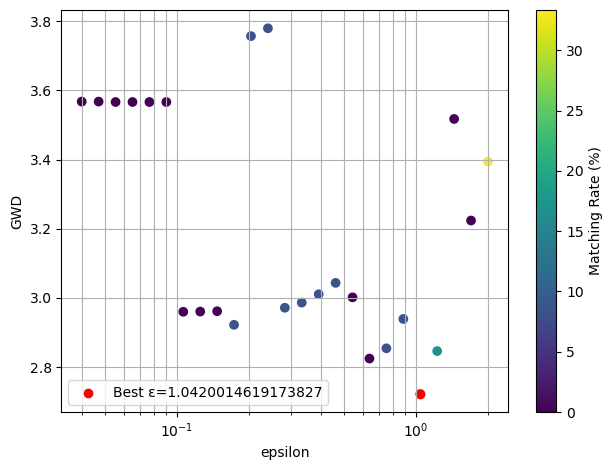

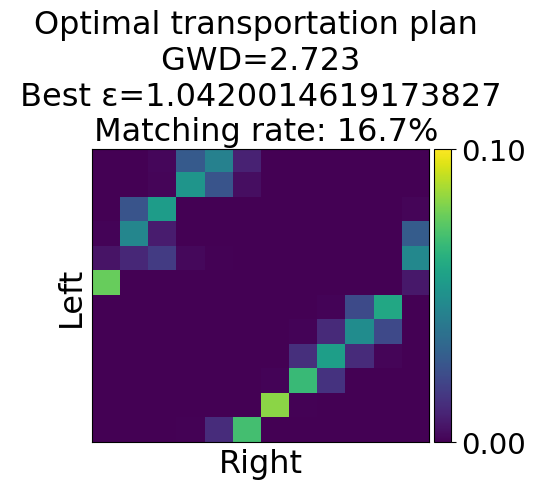

RotInv best candidate: shift_7_rot90, score=0.776
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.154741687347755, Matching Rate: 8.333333333333332
Epsilon: 0.04708151271794864, GWD: 0.16299782363720172, Matching Rate: 8.333333333333332
Epsilon: 0.055416720995258975, GWD: 0.17029397527586904, Matching Rate: 0.0
Epsilon: 0.06522757635813241, GWD: 0.1665753551357656, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 0.17211645534246034, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 0.18539270027477855, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 0.20056281432825868, Matching Rate: 8.333333333333332
Epsilon: 0.12519670795491478, GWD: 0.21328497186484618, Matching Rate: 8.333333333333332
Epsilon: 0.1473612599456155, GWD: 0.22741707921490256, Matching Rate: 8.333333333333332
Epsilon: 0.17344977585656074, GWD: 0.24377982868110798, Matching Rate: 8.333333333333332
Epsilon: 0.20415694569790008, GWD: 0.26222440417530746, Matching Rate: 8.333333333333332
Epsilon: 0.24030044588333074, GWD: 0.2818564250110504, Matching Rate: 8.3333333333

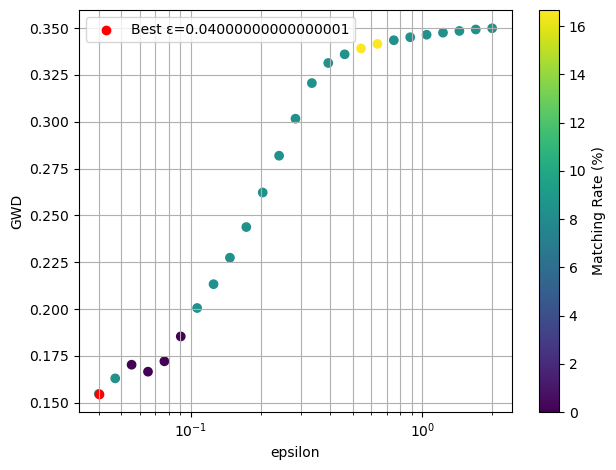

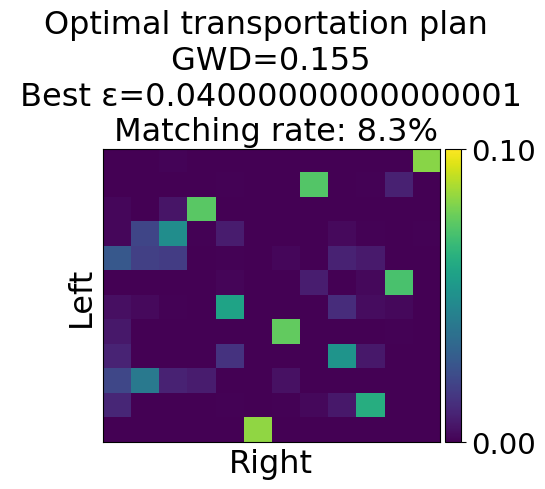

RotInv best candidate: shift_1, score=0.340


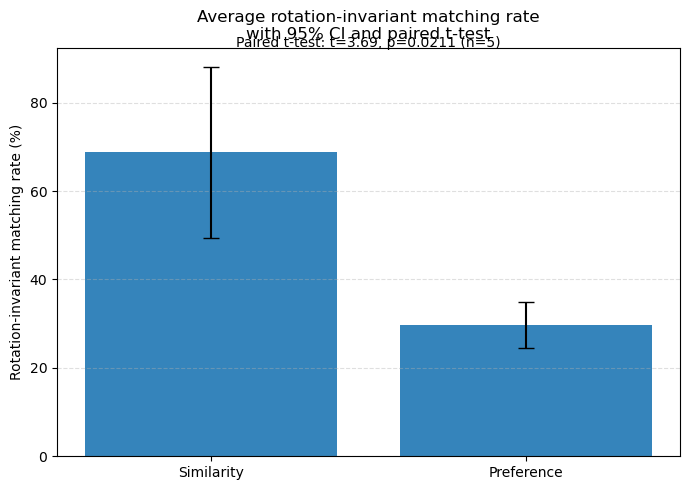


=== Rotation-invariant Matching Rate Summary ===
Similarity: mean=68.74%,  CI95±19.27
Preference: mean=29.74%,  CI95±5.21
Paired t-test: t=3.69, p=0.0211, n=5


In [ ]:
# -------------------------
# Helper: run one split → average → distance → GWOT (rot-invariant MR)
# -------------------------
def rotinv_matching_rate_for_pair(avg_raw_A: np.ndarray,
                                  avg_raw_B: np.ndarray,
                                  distance_kind: str,
                                  epsilons) -> float:
    """
    distance_kind: 'similarity' or 'preference'
    Returns the rotation-invariant maximum matching rate (%) from GWD_and_plot.
    """
    if distance_kind == "similarity":
        A_dist = compute_color_similarity_distance_batch([avg_raw_A])[0]
        B_dist = compute_color_similarity_distance_batch([avg_raw_B])[0]
    elif distance_kind == "preference":
        A_dist = compute_color_preference_distance_batch([avg_raw_A])[0]
        B_dist = compute_color_preference_distance_batch([avg_raw_B])[0]
    else:
        raise ValueError("distance_kind must be 'similarity' or 'preference'.")

    # Run GWOT with rotation-invariant scoring (we suppress candidate plot to keep it fast)
    (
        OT_plan, gwds, matching_rates, min_gwd, matching_rate,
        candidates, labels, cand_scores, rotinv_best_label, rotinv_max_score
    ) = GWD_and_plot_rotational_OT(
        A_dist, B_dist, epsilons,
        rotinv_method="fro_norm",      # or 'mass_fraction' if you prefer
        rotinv_threshold=None,         # only needed for 'threshold_hits'
        plot_candidates=False          # set True if you want the per-candidate plot each iteration
    )

    # rotinv_max_score is a similarity in [0,1] for 'fro_norm'/'mass_fraction'.
    # If you prefer % scale, multiply by 100. Here we keep it as a "rate" in % for clarity:
    # Note: If using 'mass_fraction', this percentage interpretation is natural.
    rotinv_rate_pct = float(rotinv_max_score * 100.0) if rotinv_max_score <= 1.0 else float(rotinv_max_score)
    return rotinv_rate_pct

In [ ]:
# -------------------------
# Main experiment loop
# -------------------------
if rng_seed is not None:
    random.seed(rng_seed)

rotinv_mr_similarity = []
rotinv_mr_preference = []

for it in range(n_iterations):
    # Random split 9 vs 10
    idx = list(range(n_subjects))
    random.shuffle(idx)
    g1_idx, g2_idx = idx[:9], idx[9:]

    # Average *raw* matrices first (then convert to distance) — consistent, avoids nonlinearity artifacts
    g1_sim_raw = np.mean([subject_matrices_similarity_raw[i] for i in g1_idx], axis=0)
    g2_sim_raw = np.mean([subject_matrices_similarity_raw[i] for i in g2_idx], axis=0)

    g1_pref_raw = np.mean([subject_matrices_preference_raw[i] for i in g1_idx], axis=0)
    g2_pref_raw = np.mean([subject_matrices_preference_raw[i] for i in g2_idx], axis=0)

    # Rotation-invariant matching rates for each pair (Similarity vs Preference)
    mr_sim = rotinv_matching_rate_for_pair(g1_sim_raw, g2_sim_raw, "similarity", epsilons)
    mr_pref = rotinv_matching_rate_for_pair(g1_pref_raw, g2_pref_raw, "preference", epsilons)

    rotinv_mr_similarity.append(mr_sim)
    rotinv_mr_preference.append(mr_pref)

# Convert to arrays
rotinv_mr_similarity = np.asarray(rotinv_mr_similarity, dtype=float)
rotinv_mr_preference = np.asarray(rotinv_mr_preference, dtype=float)


# -------------------------
# Statistics (paired)
# -------------------------
t_stat, p_val = ttest_rel(rotinv_mr_similarity, rotinv_mr_preference, nan_policy='omit')

def mean_ci(a):
    a = np.asarray(a, dtype=float)
    m = np.nanmean(a)
    se = np.nanstd(a, ddof=1) / np.sqrt(np.sum(~np.isnan(a)))
    ci95 = 1.96 * se
    return m, ci95

sim_mean, sim_ci = mean_ci(rotinv_mr_similarity)
pref_mean, pref_ci = mean_ci(rotinv_mr_preference)


# -------------------------
# Bar graph with 95% CI and t-test annotation
# -------------------------
fig, ax = plt.subplots(figsize=(7, 5))

x = np.array([0, 1])
means = [sim_mean, pref_mean]
cis = [sim_ci, pref_ci]
labels = ["Similarity", "Preference"]

# Bars
bars = ax.bar(x, means, yerr=cis, capsize=6, alpha=0.9)
bars[0].set_label("Rotation-invariant MR")

# Aesthetics
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Rotation-invariant matching rate (%)")
ax.set_title("Average rotation-invariant matching rate\nwith 95% CI and paired t-test")

# Grid
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# t-test annotation
annotation = f"Paired t-test: t={t_stat:.2f}, p={p_val:.3g} (n={len(rotinv_mr_similarity)})"
ax.text(0.5, max(means) + max(cis)*1.2, annotation, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
# plt.savefig("rotinv_matching_rate_comparison.png", dpi=300)
plt.show()


# -------------------------
# (Optional) quick printout
# -------------------------
print("\n=== Rotation-invariant Matching Rate Summary ===")
print(f"Similarity: mean={sim_mean:.2f}%,  CI95±{sim_ci:.2f}")
print(f"Preference: mean={pref_mean:.2f}%,  CI95±{pref_ci:.2f}")
print(f"Paired t-test: t={t_stat:.2f}, p={p_val:.3g}, n={len(rotinv_mr_similarity)}")

/var/folders/zk/lv_zrs9910s49_109vbgf6c40000gn/T/ipykernel_4716/2468028239.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


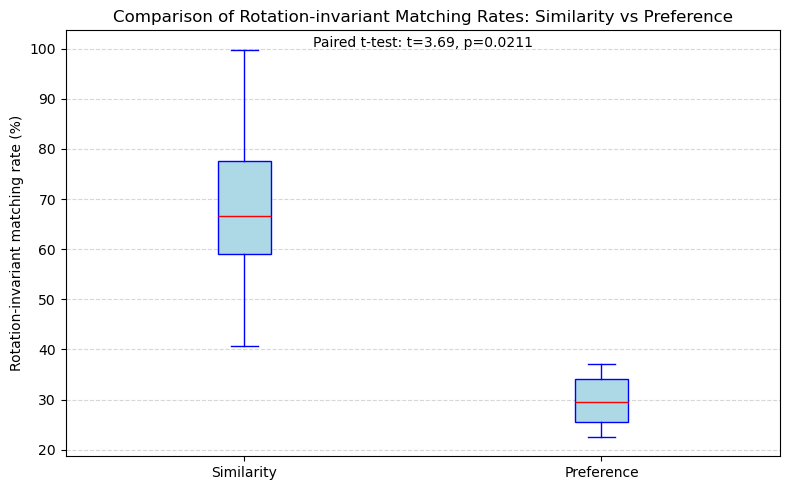

In [14]:
# -------------------------
# Box plot comparing matching rates with statistical annotation
# -------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [rotinv_mr_similarity, rotinv_mr_preference],
    labels=["Similarity", "Preference"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
)
plt.ylabel("Rotation-invariant matching rate (%)")
plt.title("Comparison of Rotation-invariant Matching Rates: Similarity vs Preference")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)

# Add statistical test annotation
annotation = f"Paired t-test: t={t_stat:.2f}, p={p_val:.3g}"
plt.text(1.5, max(max(rotinv_mr_similarity), max(rotinv_mr_preference)),  # Position above the boxes
         annotation, ha='center', va='bottom', fontsize=10, color="black")

plt.tight_layout()
plt.show()

Computing Gromov-Wasserstein distances and optimal transport plans...
Epsilon: 0.04000000000000001, GWD: 3.9439914508616405, Matching Rate: 16.666666666666664


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04708151271794864, GWD: 3.944193358630435, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 3.9443531917876062, Matching Rate: 16.666666666666664
Epsilon: 0.06522757635813241, GWD: 3.9444963526926755, Matching Rate: 16.666666666666664
Epsilon: 0.0767753241466594, GWD: 3.944683087629629, Matching Rate: 16.666666666666664
Epsilon: 0.09036746000588931, GWD: 3.944863058731042, Matching Rate: 16.666666666666664
Epsilon: 0.1063659179388998, GWD: 3.9449936784780713, Matching Rate: 16.666666666666664
Epsilon: 0.12519670795491478, GWD: 3.6407972947156084, Matching Rate: 8.333333333333332
Epsilon: 0.1473612599456155, GWD: 2.618324881346523, Matching Rate: 25.0
Epsilon: 0.17344977585656074, GWD: 2.6185850581284944, Matching Rate: 25.0
Epsilon: 0.20415694569790008, GWD: 2.1346673925868784, Matching Rate: 50.0
Epsilon: 0.24030044588333074, GWD: 2.135917206825253, Matching Rate: 50.0
Epsilon: 0.28284271247461906, GWD: 2.1385434934172247, Matching Rate: 50.0
Epsilon: 0

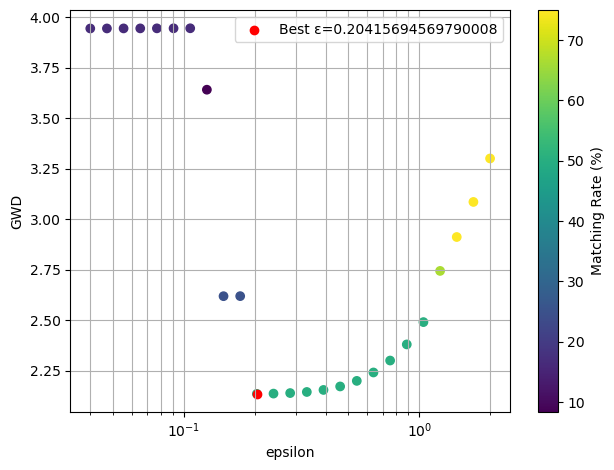

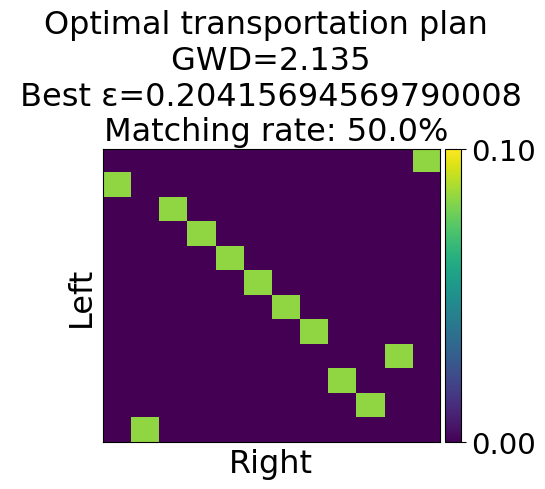

RotInv best candidate: shift_0, score=0.500
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.17086059488023808, Matching Rate: 8.333333333333332
Epsilon: 0.04708151271794864, GWD: 0.17790398155765402, Matching Rate: 8.333333333333332
Epsilon: 0.055416720995258975, GWD: 0.1845613795795163, Matching Rate: 8.333333333333332
Epsilon: 0.06522757635813241, GWD: 0.19207239953796024, Matching Rate: 8.333333333333332
Epsilon: 0.0767753241466594, GWD: 0.2026201418551813, Matching Rate: 8.333333333333332
Epsilon: 0.09036746000588931, GWD: 0.21646474693500806, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 0.22465790216995918, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 0.23445481899014153, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 0.24631207273891909, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 0.2604526740263492, Matching Rate: 0.0
Epsilon: 0.20415694569790008, GWD: 0.2764973829580127, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 0.293494611485496, Matching Rate: 0.0
Epsilon: 0.28284271247461906, GWD: 0.3

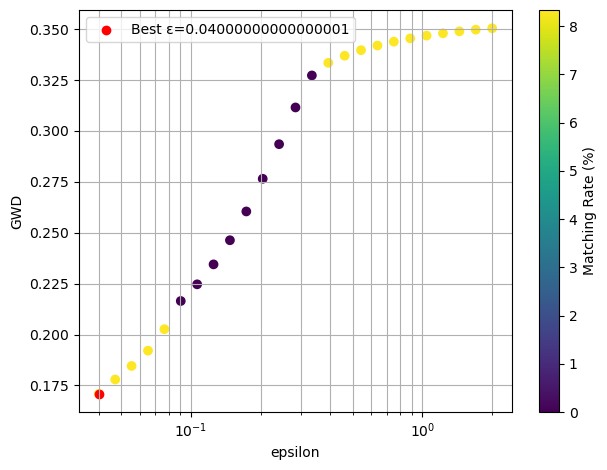

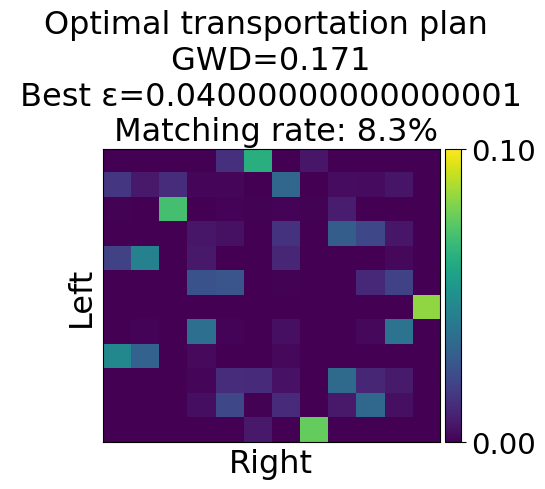

RotInv best candidate: shift_7, score=0.387
Computing Gromov-Wasserstein distances and optimal transport plans...
Epsilon: 0.04000000000000001, GWD: 3.3254073114116682, Matching Rate: 0.0
Epsilon: 0.04708151271794864, GWD: 3.325411138833286, Matching Rate: 0.0
Epsilon: 0.055416720995258975, GWD: 3.3254153547183876, Matching Rate: 0.0


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.06522757635813241, GWD: 3.3254460275519366, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 3.3255549058730196, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 3.325755630022325, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 3.3262007402755582, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 2.8290857169258903, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 3.4861943743913235, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 2.5723063352825086, Matching Rate: 0.0
Epsilon: 0.20415694569790008, GWD: 2.5690650778133293, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 2.564745111691449, Matching Rate: 0.0
Epsilon: 0.28284271247461906, GWD: 2.5596921588349657, Matching Rate: 0.0
Epsilon: 0.3329165691138216, GWD: 2.5552462568549483, Matching Rate: 0.0
Epsilon: 0.3918553920687054, GWD: 2.5522299671752755, Matching Rate: 0.0
Epsilon: 0.46122861563198747, GWD: 2.550941835898617, Matching Rate: 0.0
Epsilon: 0.5428835233189814, GWD: 2.5471859137

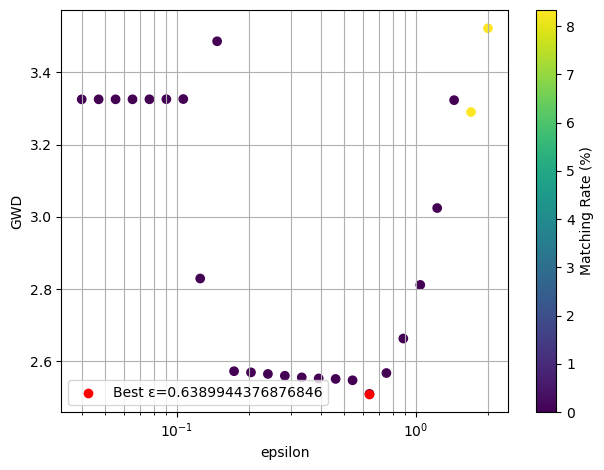

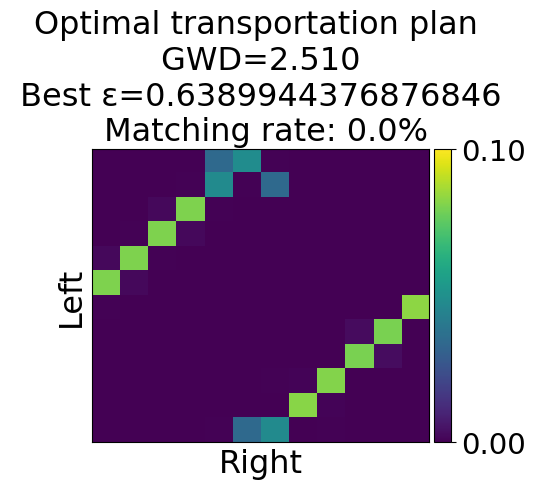

RotInv best candidate: shift_6_rot90, score=0.956
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.15291015365096222, Matching Rate: 16.666666666666664
Epsilon: 0.04708151271794864, GWD: 0.15960649399979718, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 0.1686795460429944, Matching Rate: 16.666666666666664
Epsilon: 0.06522757635813241, GWD: 0.18093995802880042, Matching Rate: 16.666666666666664
Epsilon: 0.0767753241466594, GWD: 0.1932278546829303, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 0.2069035506852696, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 0.19543270215043762, Matching Rate: 16.666666666666664
Epsilon: 0.12519670795491478, GWD: 0.2140628736813016, Matching Rate: 16.666666666666664
Epsilon: 0.1473612599456155, GWD: 0.22915183352066498, Matching Rate: 16.666666666666664
Epsilon: 0.17344977585656074, GWD: 0.24585395572471103, Matching Rate: 16.666666666666664
Epsilon: 0.20415694569790008, GWD: 0.26642403456006974, Matching Rate: 16.666666666666664
Epsilon: 0.24030044588333074, GWD: 0.291586840

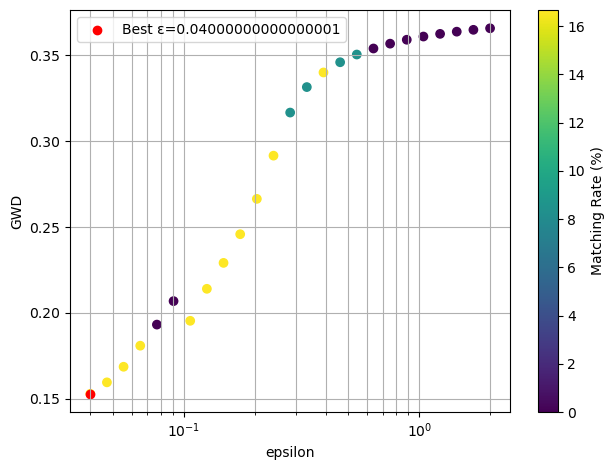

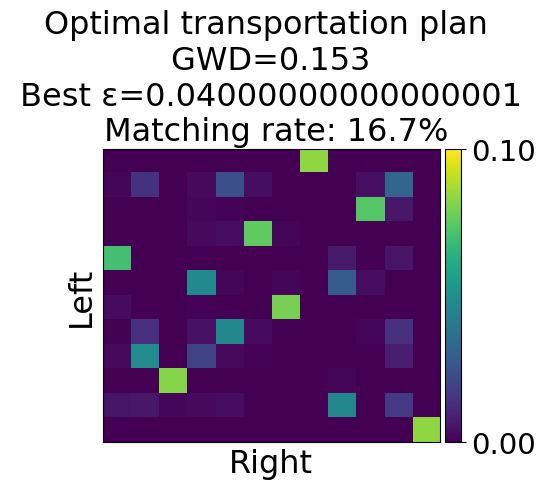

RotInv best candidate: shift_0_rot90, score=0.322
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 4.503169040785231, Matching Rate: 0.0
Epsilon: 0.04708151271794864, GWD: 4.50316924825644, Matching Rate: 0.0
Epsilon: 0.055416720995258975, GWD: 4.588165503319111, Matching Rate: 0.0
Epsilon: 0.06522757635813241, GWD: 3.974628191436066, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 3.974493619857707, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 3.9743314771743092, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 3.9742461386332186, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 3.974206492627969, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 3.9743963667835613, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 3.872010748251273, Matching Rate: 0.0
Epsilon: 0.20415694569790008, GWD: 3.87456318020433, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 3.979771910459177, Matching Rate: 0.0
Epsilon: 0.28284271247461906, GWD: 3.98490960210525, Matching Rate: 0.0
Epsilon: 0.3329165691138216, GWD: 3.9941345255255647,

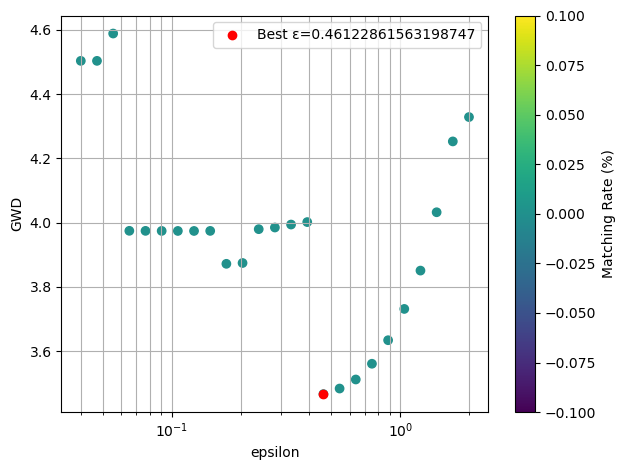

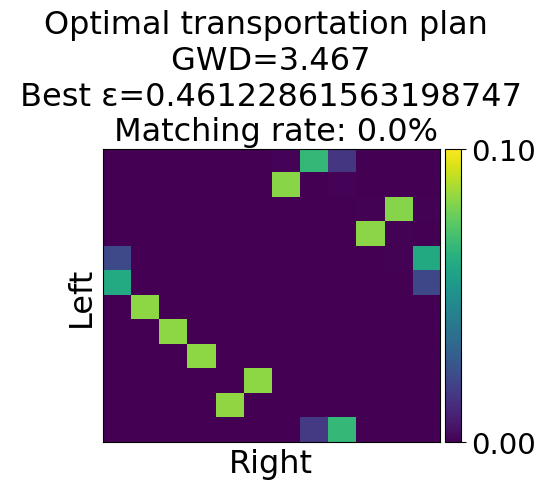

RotInv best candidate: shift_5, score=0.472
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.24104676735503483, Matching Rate: 8.333333333333332
Epsilon: 0.04708151271794864, GWD: 0.24749771402510276, Matching Rate: 8.333333333333332
Epsilon: 0.055416720995258975, GWD: 0.2563721022501696, Matching Rate: 8.333333333333332
Epsilon: 0.06522757635813241, GWD: 0.2664572808759157, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 0.27683481363923, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 0.2892762070245344, Matching Rate: 8.333333333333332
Epsilon: 0.1063659179388998, GWD: 0.30493471844126363, Matching Rate: 8.333333333333332
Epsilon: 0.12519670795491478, GWD: 0.32197305890738365, Matching Rate: 8.333333333333332
Epsilon: 0.1473612599456155, GWD: 0.3345692340638853, Matching Rate: 8.333333333333332
Epsilon: 0.17344977585656074, GWD: 0.34557624185951, Matching Rate: 25.0
Epsilon: 0.20415694569790008, GWD: 0.3581965555724561, Matching Rate: 25.0
Epsilon: 0.24030044588333074, GWD: 0.3723169445272745, Matching Rate: 25.0
Epsilon: 0.28

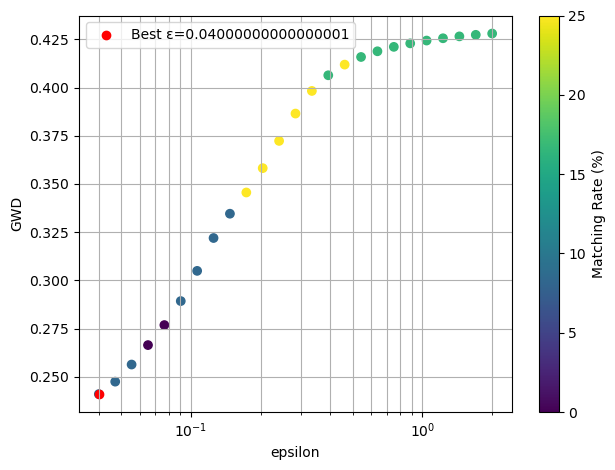

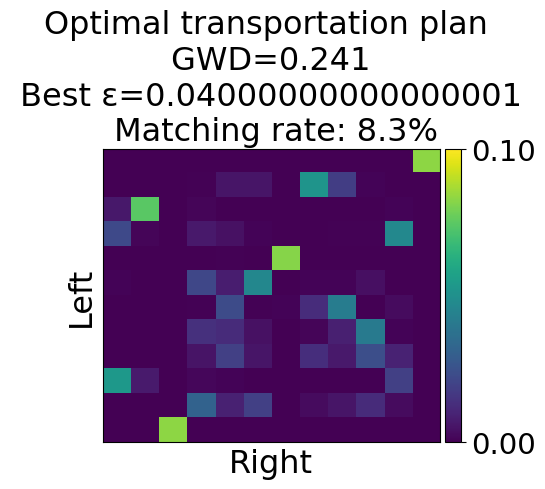

RotInv best candidate: shift_1, score=0.261
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 4.061368599948274, Matching Rate: 33.33333333333333
Epsilon: 0.04708151271794864, GWD: 4.023857443153293, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 4.404335235079659, Matching Rate: 0.0
Epsilon: 0.06522757635813241, GWD: 4.404408636414779, Matching Rate: 0.0
Epsilon: 0.0767753241466594, GWD: 4.404445212759272, Matching Rate: 0.0
Epsilon: 0.09036746000588931, GWD: 4.181849708816829, Matching Rate: 0.0
Epsilon: 0.1063659179388998, GWD: 2.992586124195345, Matching Rate: 0.0
Epsilon: 0.12519670795491478, GWD: 4.178821488212752, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 3.9850064293223033, Matching Rate: 25.0
Epsilon: 0.17344977585656074, GWD: 3.9857402556155614, Matching Rate: 25.0
Epsilon: 0.20415694569790008, GWD: 3.9881299689755885, Matching Rate: 25.0
Epsilon: 0.24030044588333074, GWD: 3.9942021347675345, Matching Rate: 25.0
Epsilon: 0.28284271247461906, GWD: 4.00661171769657, Matching Rate: 25.0
Epsilon: 0.33291

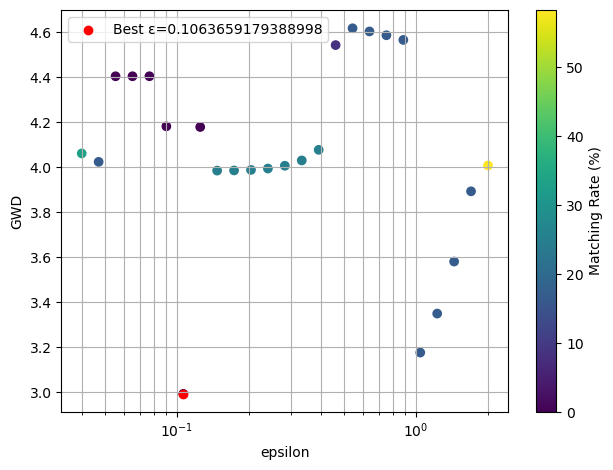

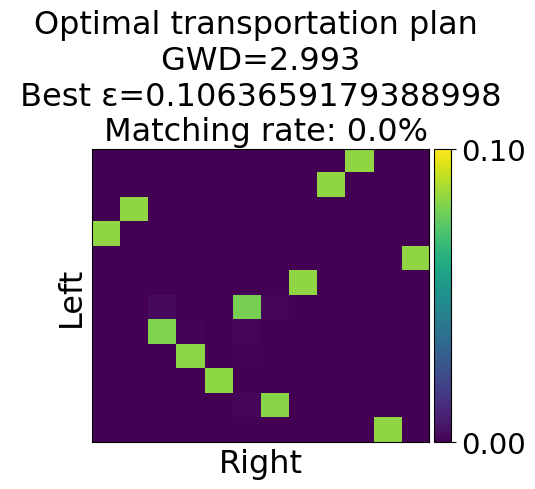

RotInv best candidate: shift_5, score=0.418
Computing Gromov-Wasserstein distances and optimal transport plans...
Epsilon: 0.04000000000000001, GWD: 0.1623834987097181, Matching Rate: 16.666666666666664


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04708151271794864, GWD: 0.1684539152165886, Matching Rate: 16.666666666666664
Epsilon: 0.055416720995258975, GWD: 0.17688089359421677, Matching Rate: 16.666666666666664
Epsilon: 0.06522757635813241, GWD: 0.18824249679818095, Matching Rate: 16.666666666666664
Epsilon: 0.0767753241466594, GWD: 0.20262450308003777, Matching Rate: 16.666666666666664
Epsilon: 0.09036746000588931, GWD: 0.21917694049593553, Matching Rate: 16.666666666666664
Epsilon: 0.1063659179388998, GWD: 0.23774294967195694, Matching Rate: 16.666666666666664
Epsilon: 0.12519670795491478, GWD: 0.25596015537518035, Matching Rate: 16.666666666666664
Epsilon: 0.1473612599456155, GWD: 0.2717883208428059, Matching Rate: 16.666666666666664
Epsilon: 0.17344977585656074, GWD: 0.2871764943583161, Matching Rate: 16.666666666666664
Epsilon: 0.20415694569790008, GWD: 0.30144005794631523, Matching Rate: 16.666666666666664
Epsilon: 0.24030044588333074, GWD: 0.3145562486389618, Matching Rate: 16.666666666666664
Epsilon: 0.28284

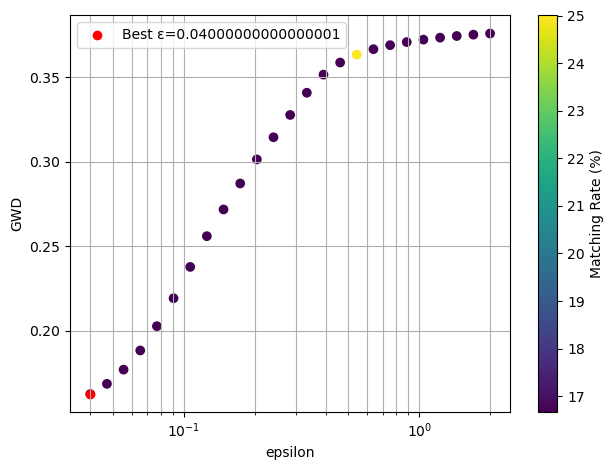

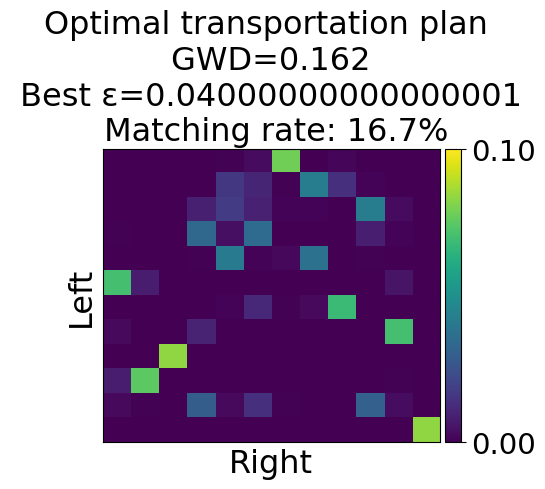

RotInv best candidate: shift_1_rot90, score=0.324
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 2.992055702700836, Matching Rate: 25.0
Epsilon: 0.04708151271794864, GWD: 3.8908887405548556, Matching Rate: 41.66666666666667
Epsilon: 0.055416720995258975, GWD: 3.889253699514228, Matching Rate: 41.66666666666667
Epsilon: 0.06522757635813241, GWD: 2.422544605821676, Matching Rate: 66.66666666666666
Epsilon: 0.0767753241466594, GWD: 2.433255959956774, Matching Rate: 66.66666666666666
Epsilon: 0.09036746000588931, GWD: 2.4498742167184626, Matching Rate: 66.66666666666666
Epsilon: 0.1063659179388998, GWD: 2.468634697088925, Matching Rate: 66.66666666666666
Epsilon: 0.12519670795491478, GWD: 2.484265755805656, Matching Rate: 66.66666666666666
Epsilon: 0.1473612599456155, GWD: 2.4964318561910335, Matching Rate: 66.66666666666666
Epsilon: 0.17344977585656074, GWD: 3.8840613860242152, Matching Rate: 41.66666666666667
Epsilon: 0.20415694569790008, GWD: 4.240478109645151, Matching Rate: 16.666666666666664
Epsilon: 0.24030044588333074, GWD: 4.216474287729959,

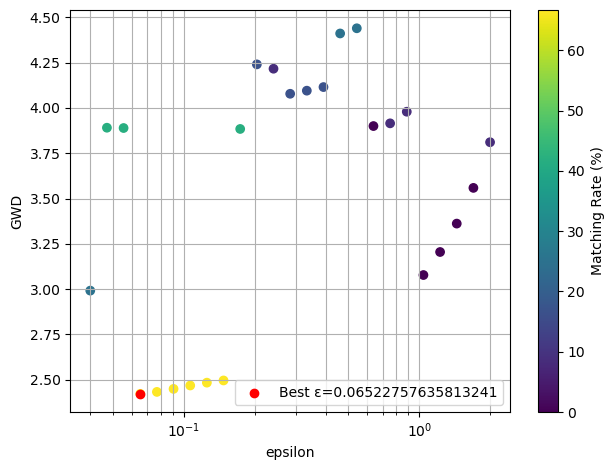

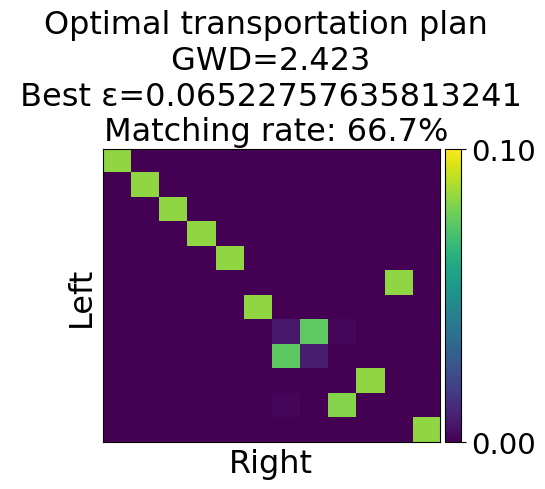

RotInv best candidate: shift_0, score=0.671
Computing Gromov-Wasserstein distances and optimal transport plans...


/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Epsilon: 0.04000000000000001, GWD: 0.6794740431172074, Matching Rate: 16.666666666666664
Epsilon: 0.04708151271794864, GWD: 0.6855391261776276, Matching Rate: 8.333333333333332
Epsilon: 0.055416720995258975, GWD: 0.6934623549238437, Matching Rate: 8.333333333333332
Epsilon: 0.06522757635813241, GWD: 0.7043381996909212, Matching Rate: 8.333333333333332
Epsilon: 0.0767753241466594, GWD: 0.719162007778937, Matching Rate: 8.333333333333332
Epsilon: 0.09036746000588931, GWD: 0.732907583120886, Matching Rate: 8.333333333333332
Epsilon: 0.1063659179388998, GWD: 0.7445677243816338, Matching Rate: 8.333333333333332
Epsilon: 0.12519670795491478, GWD: 0.7573178252473045, Matching Rate: 0.0
Epsilon: 0.1473612599456155, GWD: 0.771030866374428, Matching Rate: 0.0
Epsilon: 0.17344977585656074, GWD: 0.7855554249394485, Matching Rate: 0.0
Epsilon: 0.20415694569790008, GWD: 0.8012848878930792, Matching Rate: 0.0
Epsilon: 0.24030044588333074, GWD: 0.8189221888086377, Matching Rate: 0.0
Epsilon: 0.2828427

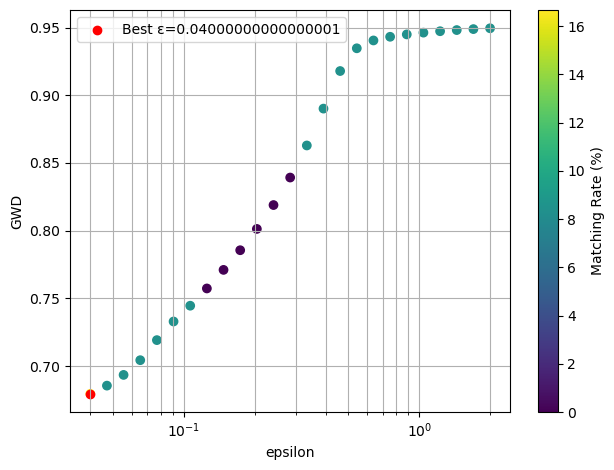

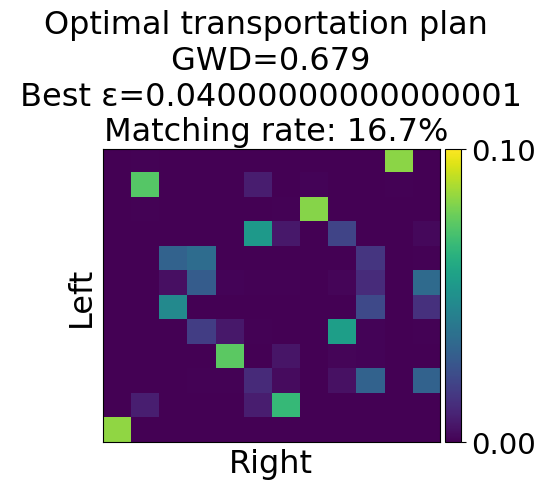

RotInv best candidate: shift_4, score=0.278


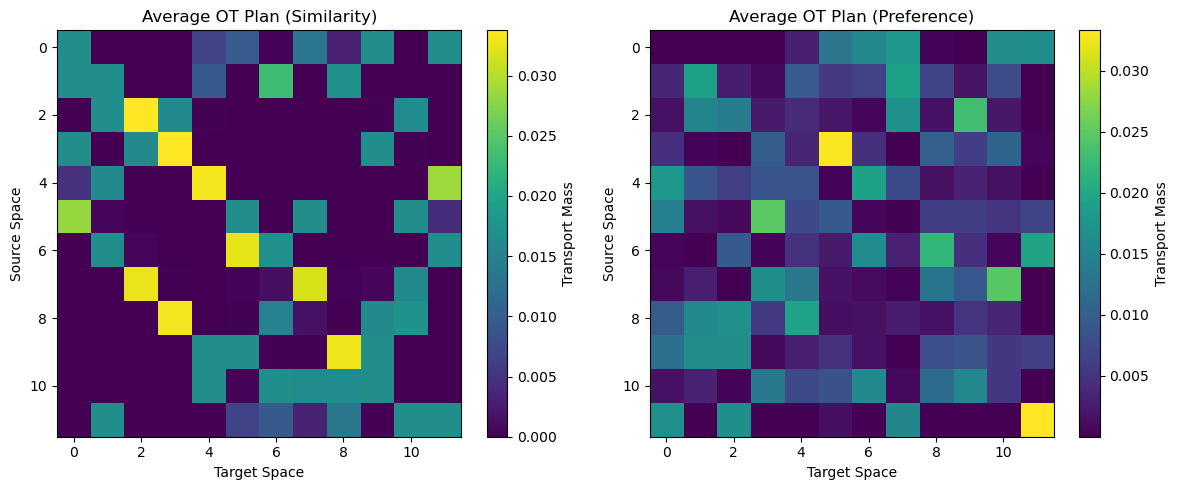

In [15]:
# -------------------------
# Store the best OT plans for each iteration
# -------------------------
best_ot_plans_similarity = []
best_ot_plans_preference = []

for it in range(n_iterations):
    # Random split 9 vs 10
    idx = list(range(n_subjects))
    random.shuffle(idx)
    g1_idx, g2_idx = idx[:9], idx[9:]

    # Average *raw* matrices first (then convert to distance)
    g1_sim_raw = np.mean([subject_matrices_similarity_raw[i] for i in g1_idx], axis=0)
    g2_sim_raw = np.mean([subject_matrices_similarity_raw[i] for i in g2_idx], axis=0)

    g1_pref_raw = np.mean([subject_matrices_preference_raw[i] for i in g1_idx], axis=0)
    g2_pref_raw = np.mean([subject_matrices_preference_raw[i] for i in g2_idx], axis=0)

    # Rotation-invariant matching rates for each pair (Similarity vs Preference)
    (
        OT_plan_sim, _, _, _, matching_rate_sim, _, _, _, _, _
    ) = GWD_and_plot_rotational_OT(
        compute_color_similarity_distance_batch([g1_sim_raw])[0],
        compute_color_similarity_distance_batch([g2_sim_raw])[0],
        epsilons,
        rotinv_method="fro_norm",
        plot_candidates=False
    )
    (
        OT_plan_pref, _, _, _, matching_rate_pref, _, _, _, _, _
    ) = GWD_and_plot_rotational_OT(
        compute_color_preference_distance_batch([g1_pref_raw])[0],
        compute_color_preference_distance_batch([g2_pref_raw])[0],
        epsilons,
        rotinv_method="fro_norm",
        plot_candidates=False
    )

    # Append the best OT plans
    best_ot_plans_similarity.append(OT_plan_sim)
    best_ot_plans_preference.append(OT_plan_pref)

# -------------------------
# Compute the average OT plans
# -------------------------
avg_ot_plan_similarity = np.mean(best_ot_plans_similarity, axis=0)
avg_ot_plan_preference = np.mean(best_ot_plans_preference, axis=0)

# -------------------------
# Plot the average OT plans
# -------------------------
plt.figure(figsize=(12, 5))

# Plot average OT plan for similarity
plt.subplot(1, 2, 1)
plt.imshow(avg_ot_plan_similarity, cmap="viridis", aspect="auto")
plt.colorbar(label="Transport Mass")
plt.title("Average OT Plan (Similarity)")
plt.xlabel("Target Space")
plt.ylabel("Source Space")

# Plot average OT plan for preference
plt.subplot(1, 2, 2)
plt.imshow(avg_ot_plan_preference, cmap="viridis", aspect="auto")
plt.colorbar(label="Transport Mass")
plt.title("Average OT Plan (Preference)")
plt.xlabel("Target Space")
plt.ylabel("Source Space")

plt.tight_layout()
plt.show()